# 12.1.1 邻域规则与同步更新

## 学习目标与先修知识

定义二值局部规则并用双缓冲核对同步演化。

先修：11.1 节点与邻域；5.4 离散状态（state）；会读 Python 列表与异或运算。

## 具体问题

一排细胞只记录激活0/1。下一时刻由左右邻居决定，而不是由画图位置决定。若边界首尾相连，单个激活细胞会怎样传播？

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

手算四格周期环 [1,0,0,0]，再写出左右旧邻居的异或。

In [2]:
print('旧状态 [1,0,0,0]；左/右旧邻居异或 → [0,1,0,1]。')

旧状态 [1,0,0,0]；左/右旧邻居异或 → [0,1,0,1]。


## 模型假设

这是元胞自动机（cellular automaton）的教学规则，不是细胞生物机制的完整描述。状态二值、只看左右两格、同步更新（synchronous update）；周期边界（periodic boundary）首尾相接，固定边界（fixed boundary）外为0。每步所有格只读同一旧状态。

## 数学解释与推导

令 $x_i^t\in\{0,1\}$，更新为 $x_i^{t+1}=x_{i-1}^t\mathbin{\mathrm{XOR}}x_{i+1}^t$。同步规则可先读完旧数组（array）、再一次性替换；若原地逐格改写，后面的格会读到 $t+1$ 值，那已是另一个模型（model）。周期边界用模 $n$ 下标；固定边界用外侧零值。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def ca_step(state, boundary, mode, order):
    """Binary rule 90: the next bit is the XOR of its two old/current neighbors."""
    n = len(state)
    result = list(state)

    def neighbor(values, index):
        if boundary == 'periodic':
            return values[index % n]
        return values[index] if 0 <= index < n else 0

    if mode == 'sync':
        old = list(state)
        return [neighbor(old, i - 1) ^ neighbor(old, i + 1) for i in range(n)]
    for i in order:
        result[i] = neighbor(result, i - 1) ^ neighbor(result, i + 1)
    return result


def ca_run(state, boundary, mode, order, steps):
    history = [list(state)]
    for _ in range(steps):
        history.append(ca_step(history[-1], boundary, mode, order))
    return history

## 对照实验

从中间单脉冲运行 25 步，用时间—位置图检查图案；再改变边界但保持其余条件。

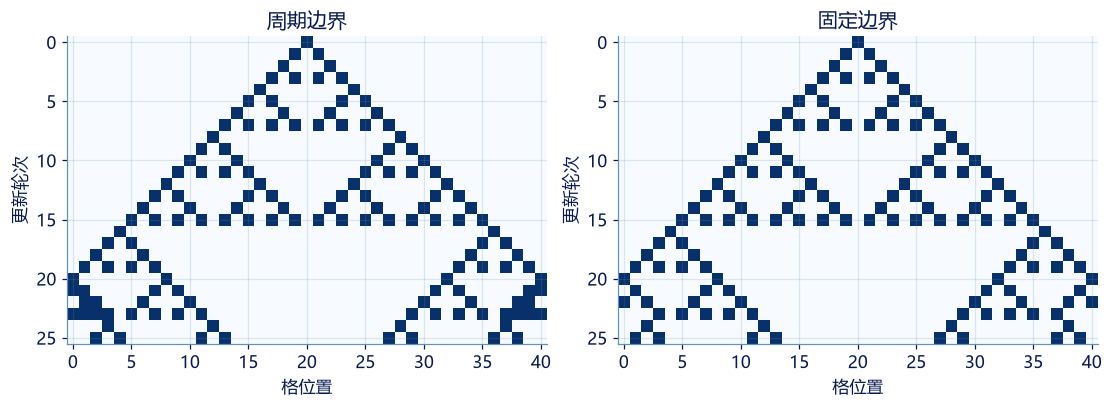

In [4]:
n=41; initial=[0]*n; initial[n//2]=1
periodic=ca_run(initial,'periodic','sync',list(range(n)),25)
fixed=ca_run(initial,'fixed','sync',list(range(n)),25)
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for ax,data,title in zip(axes,[periodic,fixed],['周期边界','固定边界']):
    ax.imshow(data,aspect='auto',interpolation='nearest',cmap='Blues',vmin=0,vmax=1)
    ax.set(xlabel='格位置',ylabel='更新轮次',title=title)
plt.show()

## 结果解释

前几轮远离边界时两图相似，触及边界后才分开。规则、初态和边界共同决定图案；两组对照的差异出现在边界影响传入以后。

### 独立核对

以四格手算例和固定端点核对实现；同步结果不受传入的遍历顺序影响。

In [5]:
assert ca_step([1,0,0,0],'periodic','sync',[0,1,2,3])==[0,1,0,1]
assert ca_step([1,0,0,0],'periodic','sync',[3,2,1,0])==[0,1,0,1]
assert ca_step([1,0,0,0],'fixed','sync',[0,1,2,3])==[0,1,0,0]
assert all(v in (0,1) for row in periodic for v in row)
print('四格手算、边界与同步顺序不变检查通过。')

四格手算、边界与同步顺序不变检查通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：按旧状态同步更新元胞

一维二值元胞的下一值等于左右邻居旧值的异或。boundary 取 periodic 或 fixed；fixed 边界外视为0。mode 固定为 sync，order 仅为统一函数接口。返回一次更新后的全部值。

**函数与代码模板**

```python
def solve(
    state: list[int],
    boundary: str,
    mode: str,
    order: list[int],
) -> list[int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[int]` | 原元胞状态（state），只含0或1，至少3格。 | 类别 |
| `boundary` | `str` | periodic 或 fixed。 | 类别 |
| `mode` | `str` | 本题为 sync。 | 类别 |
| `order` | `list[int]` | 全节点排列；同步时不影响结果。 | 编号 |

**返回值**

直接返回 updated（list[int]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `updated` | `list[int]` | 同时读取旧状态所得的新状态。 | 类别 |

**计算规则**

第 i 格新值=旧左邻居 XOR 旧右邻居；同步规则不读取本步刚写入的值。

**约束与边界**

- 只使用题定的有限状态、固定输入（input）与明示更新规则；不从图形猜测答案。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 原元胞状态（state），只含0或1，至少3格。 | [1, 0, 0, 0] | 类别 |
| boundary | periodic 或 fixed。 | periodic | 类别 |
| mode | 本题为 sync。 | sync | 类别 |
| order | 全节点排列；同步时不影响结果。 | [0, 1, 2, 3] | 编号 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [1, 0, 0, 0]
boundary = 'periodic'
mode = 'sync'
order = [0, 1, 2, 3]

result = solve(state, boundary, mode, order)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| updated | 同时读取旧状态所得的新状态。 | [0, 1, 0, 1] | 类别 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0, 1, 0, 1]
```

**样例解释**

周期四格单脉冲向两边传播；固定边界（fixed boundary）的左端不从右端读值。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：按旧状态同步更新元胞](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/practice/?question=p12-ca-synchronous)

### 第 2 题 · 单项选择题：为何需要双缓冲

从左到右逐格修改原数组（array），却声称实现同步规则。问题出在哪里？

- **A.** 后面格可能读到本步新值。
- **B.** 这样自动等于周期边界（periodic boundary）。
- **C.** 异或不能用于二值状态（state）。
- **D.** 只要动画相似就等价。

[作答：为何需要双缓冲](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/practice/?question=p12-old-state-buffer)

### 第 3 题 · 单项选择题：单脉冲的周期结果

四格周期环初态[1,0,0,0]，左右旧邻居异或同步更新（synchronous update）一次，结果是什么？

- **A.** [0,1,0,1]
- **B.** [0,1,0,0]
- **C.** [1,1,1,1]
- **D.** [0,0,0,0]

[作答：单脉冲的周期结果](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/practice/?question=p12-periodic-single)

### 第 4 题 · 多项选择题：局部规则应声明什么

要让另一位学习者复现元胞实验，哪些信息是必要的？

- **A.** 状态（state）取值、邻域与边界。
- **B.** 是否同步及旧状态读写约定。
- **C.** 图像边框颜色。
- **D.** 播放按钮的动效时长。

[作答：局部规则应声明什么](http://127.0.0.1:8000/chapters/12-01-%E5%A4%9A%E4%B8%BB%E4%BD%93%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%85%83%E8%83%9E%E8%87%AA%E5%8A%A8%E6%9C%BA/practice/?question=p12-rule-definition)

**进一步阅读**

[SFI Complexity Explorer 的复杂系统课程](https://www.complexityexplorer.org/courses/185-introduction-to-complexity/faq)提供局部规则与群体现象的后续阅读；本节规则与边界均已明示。